# Shapley Attribution — Reproducible Benchmark

Verifies all claims in the README benchmark section.

- **Benchmark A**: undirected data, set-based ground truth (Dirichlet channel importances)
- **Benchmark B**: directed data (`directed_interaction_strength=0.6`), oracle ordered ground truth

Settings: 8 channels, 5000 journeys, 2000 MC iterations, `random_state=42`.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 110

from shapley_attribution import (
    MonteCarloShapleyAttribution, PathShapleyAttribution,
    SimplifiedShapleyAttribution,
    FirstTouchAttribution, LastTouchAttribution,
    LinearAttribution, TimeDecayAttribution, PositionBasedAttribution,
    make_attribution_problem,
    normalized_mean_absolute_error, rank_correlation, top_k_overlap,
    plot_performance,
)
from shapley_attribution.metrics import attribution_summary

print("All imports OK")

All imports OK


---
## Benchmark A — Undirected data, set-based ground truth

No directed interactions. Ground truth = normalized Dirichlet channel importances (set-based).
Evaluates how well each model recovers the true per-channel importance when ordering is not a factor.

In [2]:
journeys, conversions, ground_truth, channels = make_attribution_problem(
    n_channels=8,
    n_journeys=5000,
    random_state=42,
    # No max_journey_length cap, no directed_interaction_strength
)

print(f"Journeys: {len(journeys):,}  |  Conversions: {conversions.sum():,} ({conversions.mean():.1%})")
print(f"Ground truth (set-based): {dict(zip([f'Ch{c}' for c in channels], ground_truth.round(4)))}")

Journeys: 5,000  |  Conversions: 1,510 (30.2%)
Ground truth (set-based): {'Ch0': np.float64(0.132), 'Ch1': np.float64(0.0716), 'Ch2': np.float64(0.0647), 'Ch3': np.float64(0.0647), 'Ch4': np.float64(0.3129), 'Ch5': np.float64(0.1669), 'Ch6': np.float64(0.0498), 'Ch7': np.float64(0.1375)}


In [3]:
models_a = {
    'First Touch'       : FirstTouchAttribution(),
    'Last Touch'        : LastTouchAttribution(),
    'Linear'            : LinearAttribution(),
    'Time Decay'        : TimeDecayAttribution(decay_rate=0.5),
    'Position Based'    : PositionBasedAttribution(),
    'Simplified Shapley': SimplifiedShapleyAttribution(),
    'MC Shapley'        : MonteCarloShapleyAttribution(n_iter=2000, random_state=42),
    'Path Shapley'      : PathShapleyAttribution(random_state=42),
}

results_a = {}
timings_a = {}
for name, model in models_a.items():
    t0 = time.perf_counter()
    model.fit(journeys, y=conversions)
    timings_a[name] = time.perf_counter() - t0
    arr = model.get_attribution_array()
    results_a[name] = {
        'nmae'            : normalized_mean_absolute_error(arr, ground_truth),
        'rank_correlation': rank_correlation(arr, ground_truth),
        'top_3_overlap'   : top_k_overlap(arr, ground_truth, k=3),
    }

df_a = pd.DataFrame(results_a).T.round(4)
df_a.columns = ['NMAE ↓', 'Rank Corr ↑', 'Top-3 ↑']
df_a['Time (s)'] = pd.Series(timings_a).round(3)
df_a.sort_values('NMAE ↓')

,NMAE ↓,Rank Corr ↑,Top-3 ↑,Time (s)
Path Shapley,0.0195,0.9762,0.6667,0.453
MC Shapley,0.0221,0.9762,1.0000,0.472
Time Decay,0.0445,0.9762,1.0000,0.006
Last Touch,0.0446,0.9701,1.0000,0.003
Simplified Shapley,0.0455,1.0000,1.0000,0.006
Linear,0.0457,0.9524,1.0000,0.005
Position Based,0.0461,0.9762,0.6667,0.005
First Touch,0.0481,0.7619,0.6667,0.004


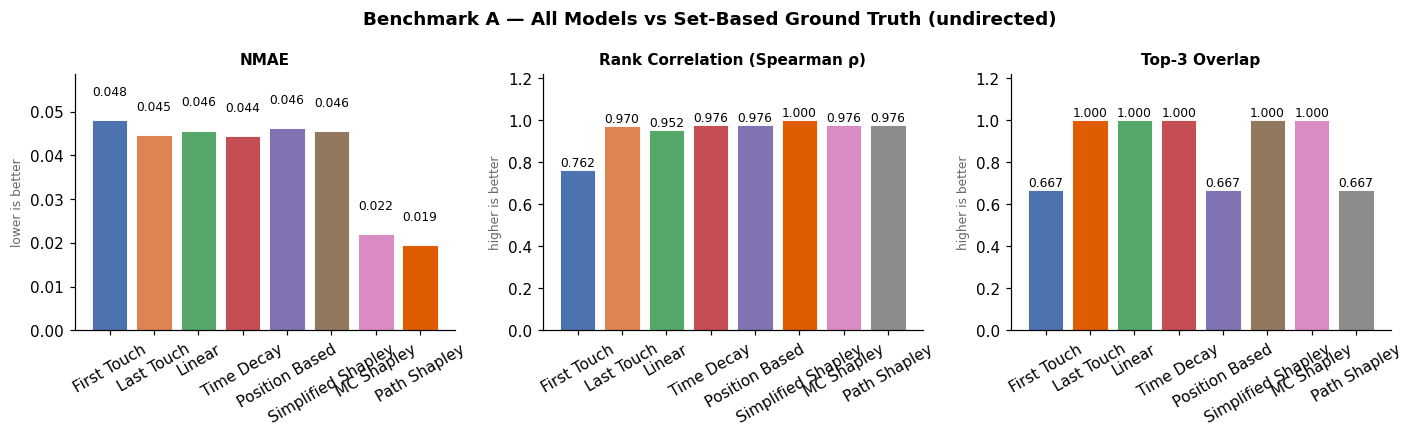

array([<Axes: title={'center': 'NMAE'}, ylabel='lower is better'>,
       <Axes: title={'center': 'Rank Correlation (Spearman ρ)'}, ylabel='higher is better'>,
       <Axes: title={'center': 'Top-3 Overlap'}, ylabel='higher is better'>],
      dtype=object)

In [4]:
plot_performance(results_a, title='Benchmark A — All Models vs Set-Based Ground Truth (undirected)')

---
## Benchmark B — Directed data, oracle ordered ground truth

`directed_interaction_strength=0.6` bakes asymmetric sequential synergies into the conversion model: channel i appearing *before* j contributes differently than j appearing before i.

The oracle ground truth is computed by walking each converting journey through the true logistic model and accumulating prefix-based marginal contributions — the exact quantity PathShapleyAttribution is designed to recover.

Set-based models (MC Shapley, all heuristics) are evaluated against this ordered ground truth, which measures how blind they are to ordering effects.

In [5]:
journeys_d, conv_d, gt_d, ch_d, ordered_gt = make_attribution_problem(
    n_channels=8,
    n_journeys=5000,
    directed_interaction_strength=0.6,
    return_ordered_ground_truth=True,
    random_state=42,
)

print(f"Journeys: {len(journeys_d):,}  |  Conversions: {conv_d.sum():,} ({conv_d.mean():.1%})")
print()

gt_compare = pd.DataFrame({
    'Set-based GT'  : gt_d,
    'Ordered GT'    : ordered_gt,
}, index=[f'Ch {c}' for c in ch_d]).round(4)

print("Note: ordered GT can differ substantially from set-based GT when directed interactions are strong")
gt_compare.sort_values('Ordered GT', ascending=False)

Journeys: 5,000  |  Conversions: 1,511 (30.2%)

Note: ordered GT can differ substantially from set-based GT when directed interactions are strong


,Set-based GT,Ordered GT
Ch 5,0.1669,0.2745
Ch 4,0.3129,0.1935
Ch 2,0.0647,0.1289
Ch 1,0.0716,0.1236
Ch 7,0.1375,0.1189
Ch 3,0.0647,0.0876
Ch 0,0.1320,0.0654
Ch 6,0.0498,0.0075


In [6]:
models_b = {
    'First Touch'       : FirstTouchAttribution(),
    'Last Touch'        : LastTouchAttribution(),
    'Linear'            : LinearAttribution(),
    'Time Decay'        : TimeDecayAttribution(decay_rate=0.5),
    'Position Based'    : PositionBasedAttribution(),
    'Simplified Shapley': SimplifiedShapleyAttribution(),
    'MC Shapley'        : MonteCarloShapleyAttribution(n_iter=2000, random_state=42),
    'Path Shapley'      : PathShapleyAttribution(random_state=42),
}

results_b = {}
timings_b = {}
for name, model in models_b.items():
    t0 = time.perf_counter()
    model.fit(journeys_d, y=conv_d)
    timings_b[name] = time.perf_counter() - t0
    arr = model.get_attribution_array()
    results_b[name] = {
        'nmae'            : normalized_mean_absolute_error(arr, ordered_gt),
        'rank_correlation': rank_correlation(arr, ordered_gt),
        'top_3_overlap'   : top_k_overlap(arr, ordered_gt, k=3),
    }

df_b = pd.DataFrame(results_b).T.round(4)
df_b.columns = ['NMAE ↓', 'Rank Corr ↑', 'Top-3 ↑']
df_b['Time (s)'] = pd.Series(timings_b).round(3)
df_b.sort_values('NMAE ↓')

,NMAE ↓,Rank Corr ↑,Top-3 ↑,Time (s)
Path Shapley,0.0399,0.6667,0.6667,0.453
Last Touch,0.0404,0.7306,0.6667,0.004
Time Decay,0.0407,0.6905,0.6667,0.006
Simplified Shapley,0.0423,0.7619,0.6667,0.006
Linear,0.0427,0.7143,0.6667,0.005
Position Based,0.0429,0.6667,0.6667,0.005
First Touch,0.0474,0.2619,0.3333,0.004
MC Shapley,0.0503,0.5952,0.6667,0.481


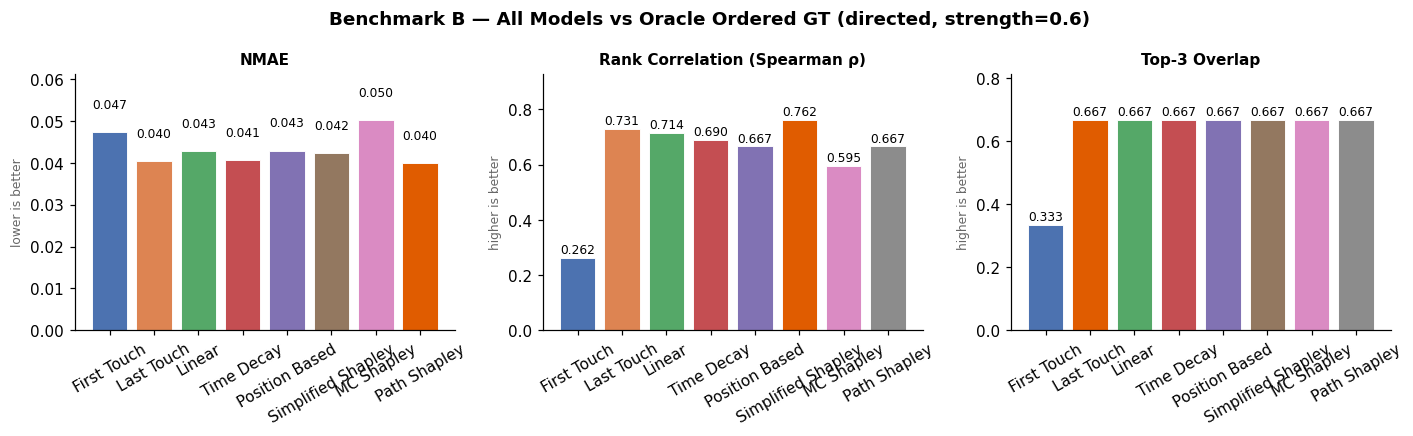

array([<Axes: title={'center': 'NMAE'}, ylabel='lower is better'>,
       <Axes: title={'center': 'Rank Correlation (Spearman ρ)'}, ylabel='higher is better'>,
       <Axes: title={'center': 'Top-3 Overlap'}, ylabel='higher is better'>],
      dtype=object)

In [7]:
plot_performance(results_b, title='Benchmark B — All Models vs Oracle Ordered GT (directed, strength=0.6)')

---
## Summary — README claims verified

In [8]:
summary = pd.DataFrame({
    'Benchmark A — Undirected (vs set GT)': {
        'Path Shapley NMAE': results_a['Path Shapley']['nmae'],
        'MC Shapley NMAE'  : results_a['MC Shapley']['nmae'],
        'Path beats MC?'   : results_a['Path Shapley']['nmae'] < results_a['MC Shapley']['nmae'],
        'Path rank #1?'    : df_a['NMAE ↓'].sort_values().index[0] == 'Path Shapley',
    },
    'Benchmark B — Directed (vs ordered GT)': {
        'Path Shapley NMAE': results_b['Path Shapley']['nmae'],
        'MC Shapley NMAE'  : results_b['MC Shapley']['nmae'],
        'Path beats MC?'   : results_b['Path Shapley']['nmae'] < results_b['MC Shapley']['nmae'],
        'Path rank #1?'    : df_b['NMAE ↓'].sort_values().index[0] == 'Path Shapley',
    },
}).T

print("README claim: 'Path Shapley achieves lower NMAE in both undirected and directed settings'")
print()
summary

README claim: 'Path Shapley achieves lower NMAE in both undirected and directed settings'



,Path Shapley NMAE,MC Shapley NMAE,Path beats MC?,Path rank #1?
Benchmark A — Undirected (vs set GT),0.019453,0.022057,True,True
Benchmark B — Directed (vs ordered GT),0.039858,0.050258,True,True
